In [2]:
from math import *
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.stats as ss

In [3]:
def impvol(S, r, T, K, C_market, sigma_0, tol):

    """
    Function that calculates implied volatility using Newton-Raphson method
    
        sigma(k+1) = sigma(k) - (C(sigma(k))- C_market)/kappa, 
    
    where sigma0 is an initial guess of volatility

    Input: 
          S       -> Stock price
          r       -> Interest rate
          T       -> Maturity
          K       -> Strike price
          C_market-> European option value (given)
          sigma_0 -> initial guess of implied volatility
          tol     -> tolerance for NR method

    Output:
         im_sigma -> Implied volatility
    """
    # setting up the black scholes formula
    max_iter = 1000
    im_sigma = sigma_0
    for i in range(max_iter):
        d1 = (np.log(S/K) + (r + (im_sigma**2)/2)*T)/(im_sigma*np.sqrt(T))
        d2 = (np.log(S/K) + (r - (im_sigma**2)/2)*T)/(im_sigma*np.sqrt(T))
        # d2 = d1 - im_sigma*np.sqrt(T)
        C_K = S*ss.norm.cdf(d1) - K*np.exp(-r*(T))*ss.norm.cdf(d2)
        kappa = S*np.sqrt(T)*ss.norm.pdf(d1)

        # calculating the next sigma
        sigma_new = im_sigma - (C_K - C_market)/kappa
        # making comparison between the new and old sigmas
        if np.abs(sigma_new - im_sigma) < tol:
            return sigma_new
        im_sigma = sigma_new

In [4]:
# Input parameters
sigma_0 = 0.1
K = [*range(124, 137, 1)]
S0 = 129
r = 0
T = 30/360
C_market = [6.03, 5.23, 4.49, 3.79, 3.14, 2.55, 2.02, 1.59, 1.26, 1.00, 0.81, 0.67, 0.55]
tol = 1e-10

Text(0.5, 1.0, 'implied volatility for different strike price values')

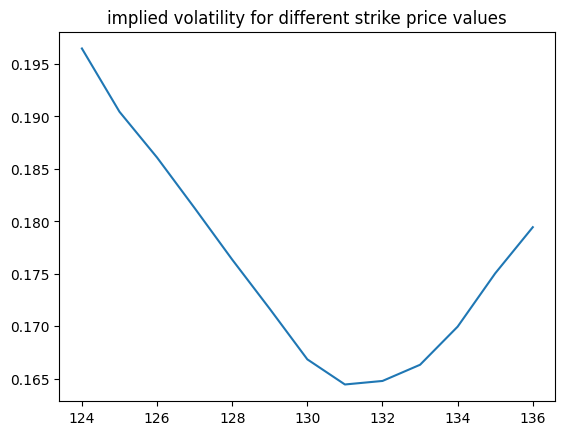

In [5]:
# Implement impvol function to calculate the implied volatility for each strike price and option price
sigmas = []

for k, c in zip(K , C_market):
    sigmas.append(impvol(S0, r, T, k, c, sigma_0, tol))
sigmas
plt.plot(K , sigmas)
plt.title('implied volatility for different strike price values')

### Will the implied volatilities using the corresponding market prices of European puts be the same?

In [6]:
print('the implied volatility using the European Put option must be the same. due the put-call parity, there should be consistency between the call and put. also the black scholes formula uses the same sigma which mean in case there is difference in sigma calculated by the corresponding put and call formula, there would be arbitrage opportunity (mainly due to inconsistency in put call parity)')
# Add code here

the implied volatility using the European Put option must be the same. due the put-call parity, there should be consistency between the call and put. also the black scholes formula uses the same sigma which mean in case there is difference in sigma calculated by the corresponding put and call formula, there would be arbitrage opportunity (mainly due to inconsistency in put call parity)


In [7]:
# New input
Time = [1/12, 1/4, 1/2, 1]
Value = [2.55, 4.49, 6.70, 10.13]
Price = 129
Strike = 129
Rate = 0
Sigma_0 = 0.2
Tol = 1e-10

## Apply NR for the new input

In [8]:
new_sigmas = []
for t,c in zip(Time , Value):
    new_sigmas.append(impvol(Price, Rate, t, Strike, c, Sigma_0, Tol))

In [9]:
def func(t, sigma_0, a, b):
    """
    Function that creates the time dependent volatility function
        sigma(t) = sigma_0 * exp(−a*t) + b*(1−exp(−a*t))
    Input: 
          t       -> time
          sigma_0 -> Parameter
          a       -> Parameter
          b       -> Parameter
          
    Output:
         sigma(t) -> Time dependent volatility
    """
    return sigma_0*np.exp(-a*t) + b*(1- np.exp(-a*t))

In [10]:
opts , opts_cov = opt.curve_fit(func , Time , new_sigmas)
sigma0_optimized = opts[0]
a_optimized = opts[1]
b_optimized = opts[2]
print(f'sigma0_optimized  = {sigma0_optimized:.6f}')
print(f'a_optimized = {a_optimized:.6f}')
print(f'b_optimized = {b_optimized:.6f}')

sigma0_optimized  = 0.168393
a_optimized = 0.140050
b_optimized = 0.389584


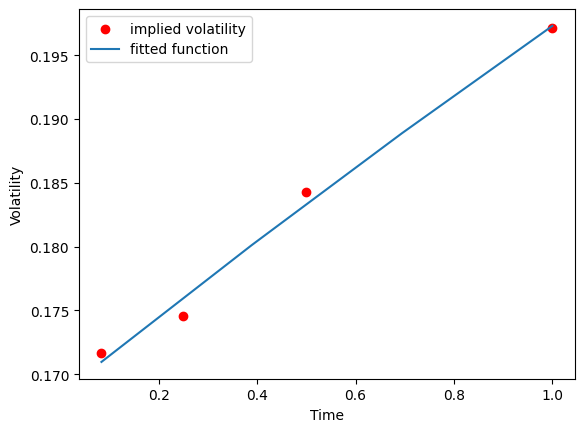

In [11]:
# Add your code here
t = np.linspace(1/12 ,1 , len(Time))
func_array = func(t , sigma0_optimized , a_optimized , b_optimized)
plt.scatter(Time , new_sigmas , color = 'red' , label = "implied volatility")
plt.plot(t ,func_array , label = "fitted function")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.show()